In [10]:
# ============================================================
# Fk_fitting_SF3_Bayesian_RLS_Lcurve_uncertainty4
# ============================================================
import numpy as np
import xarray as xr
from scipy.special import jv
from scipy.linalg import inv
import os
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy.linalg import solve

import sys
import importlib
sys.path.insert(0, '/meddy/simingzhang/Analysis/python/python3/')

import RLS_Bayesian
RLS_Bayesian = importlib.reload(RLS_Bayesian)

from RLS_Bayesian import *

# 1.  process r to same bin of particles (jump if already process)

In [2]:
# Eulname='/meddy/simingzhang/Analysis/matlab/nowave_Eulerian_SF3.mat'
# data=sio.loadmat(Eulname)
# S3L1=data['S3L1']
# S3T1=data['S3T1']
# N=287
# xscale=np.squeeze(data['xscale'])
# r, SF3, S3L1, S3T1=calc_radial(S3L1, S3T1, N, xscale)
# dist_axis, SF3_binned, counts=bin_SF3_by_dist_axis(dist_axis, r, SF3)
# sio.savemat('/meddy/simingzhang/Data/Parcels_data/nowave_Eulerian_bin_SF3.mat',{'dist_axis':dist_axis[np.newaxis,:-1],'SF3':SF3_binned[:-1,np.newaxis]})

# 2. RLS fiting vs Coarse graining

In [3]:
cgname='/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_smooth_kaiser_corr.0002.nc'
cg=xr.open_dataset(cgname)
filtscale=np.squeeze(cg['filtscale'][1:])
Th_Eul=cg['Thm'].values[1:]
# Lagname = f"/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughdistr_tukey/wave_pars_P1089T1940_roughbootstrap.mat"
Lagname=f'/meddy/simingzhang/Data/Parcels_data/tranV_onetime_roughsmallregion/nowave_pars_P289T1940_roughsmallbootstrap.mat'

data=sio.loadmat(Lagname)
Th_lag=np.mean(data['Th_all'],axis=1)

dist_axis, Y, Y_std, optimal_fac, optimal_po, res=Fk_fitting_SF3_Bayesian_RLS_Lcurve_uncertainty4(
    Lagname,
    2.7e3, 350e3, 7,
    n_bootstrap=100, bootstrap_size=500
)

L-curve prior：
  fac0 = 1.418726674116599e-08
  po   = 9.999999999999999e-06
Bootstrap 1/100
Bootstrap 2/100
Bootstrap 3/100
Bootstrap 4/100
Bootstrap 5/100
Bootstrap 6/100
Bootstrap 7/100
Bootstrap 8/100
Bootstrap 9/100
Bootstrap 10/100
Bootstrap 11/100
Bootstrap 12/100
Bootstrap 13/100
Bootstrap 14/100
Bootstrap 15/100
Bootstrap 16/100
Bootstrap 17/100
Bootstrap 18/100
Bootstrap 19/100
Bootstrap 20/100
Bootstrap 21/100
Bootstrap 22/100
Bootstrap 23/100
Bootstrap 24/100
Bootstrap 25/100
Bootstrap 26/100
Bootstrap 27/100
Bootstrap 28/100
Bootstrap 29/100
Bootstrap 30/100
Bootstrap 31/100
Bootstrap 32/100
Bootstrap 33/100
Bootstrap 34/100
Bootstrap 35/100
Bootstrap 36/100
Bootstrap 37/100
Bootstrap 38/100
Bootstrap 39/100
Bootstrap 40/100
Bootstrap 41/100
Bootstrap 42/100
Bootstrap 43/100
Bootstrap 44/100
Bootstrap 45/100
Bootstrap 46/100
Bootstrap 47/100
Bootstrap 48/100
Bootstrap 49/100
Bootstrap 50/100
Bootstrap 51/100
Bootstrap 52/100
Bootstrap 53/100
Bootstrap 54/100
Bootstrap 55/1

In [4]:
def plot_L_curve(Lcurve, savepath=None):
    """
    Plot L-curve from precomputed Lcurve dictionary.
    Does NOT perform any computation.

    Parameters
    ----------
    Lcurve : dict
        Must contain:
        - residual_norms
        - solution_norms
        - po_range
        - fac0_range
        - po_idx
        - fac0_idx
    savepath : str, optional
        If given, save figure to path
    """
    residual_norms = Lcurve["residual_norms"]
    solution_norms = Lcurve["solution_norms"]
    po_range = Lcurve["po_range"]
    fac0_range = Lcurve["fac0_range"]
    po_idx = Lcurve["po_idx"]
    fac0_idx = Lcurve["fac0_idx"]

    fig, ax = plt.subplots(figsize=(6, 5))

    # ---- Scatter (L-curve) ----
    X = residual_norms.flatten()
    Y = solution_norms.flatten()

    sc = ax.scatter(
        X, Y,
        c=np.log10(Y),
        cmap="viridis",
        s=20,
        alpha=0.8
    )

    # ---- Corner point ----
    opt_res = residual_norms[po_idx, fac0_idx]
    opt_sol = solution_norms[po_idx, fac0_idx]

    ax.scatter(
        opt_res, opt_sol,
        c="red", s=150, marker="*",
        label="Selected corner"
    )

    # ---- Labels ----
    ax.set_xlabel(r"$||W^{-1/2}(Y - A\epsilon)||_2$")
    ax.set_ylabel(r"$||\epsilon||_2$")
    ax.set_title("L-curve for Bayesian RLS prior selection")

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", linestyle="--", alpha=0.5)

    # ========== 关键修正：同时设置 X 和 Y 轴 ==========
    # 1. 裁剪 X 轴（最重要！）
    # 你的红点在 X=1~2 之间，把右边的大值切掉
    # ax.set_xlim(left=0.8, right=5)  # <-- 重点在这里

    # 2. 修正 Y 轴（合并为一行）
    # 根据你的数值 1e-8 和 1e-5，这个范围最合适
    # ax.set_ylim(bottom=1e-5, top=1e-3)  # <-- 去掉了重复的设置
    # ==================================================

    ax.legend(fontsize=9)
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
    plt.show()

In [5]:
# plot_L_curve(res.Lcurve)


In [81]:
kf_lag=res.kf_final/2/np.pi
Fk_lag=np.nanmean(res.Fk_all,axis=1)
Fk_lag_std=np.nanstd(res.Fk_all,axis=1)*10



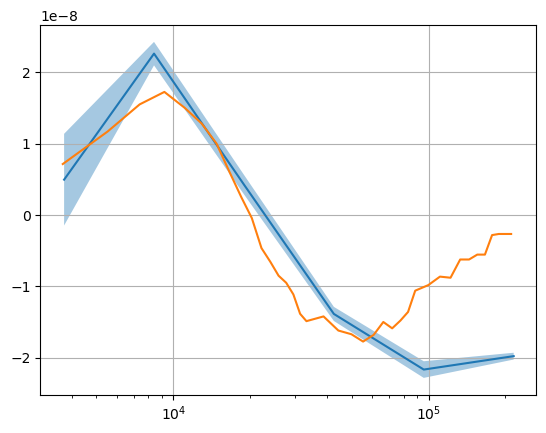

In [82]:
plt.semilogx(1/kf_lag,Fk_lag)
plt.semilogx(filtscale,Th_lag)
plt.fill_between(1/kf_lag,Fk_lag+Fk_lag_std,Fk_lag-Fk_lag_std,alpha=0.4)
plt.grid(True)

In [54]:
dist_axis, Y, Y_std, optimal_fac, optimal_po, res=Fk_fitting_SF3_Bayesian_RLS_Lcurve_uncertainty4(
    '/meddy/simingzhang/Data/Parcels_data/nowave_Eulerian_bin_SF3.mat',
    3e3, 350e3, 9,
    n_bootstrap=100, bootstrap_size=500
)

L-curve prior：
  fac0 = 1.8988078244652693e-18
  po   = 1.0000000000000001e-20
Bootstrap 1/100
Bootstrap 2/100
Bootstrap 3/100
Bootstrap 4/100
Bootstrap 5/100
Bootstrap 6/100
Bootstrap 7/100
Bootstrap 8/100
Bootstrap 9/100
Bootstrap 10/100
Bootstrap 11/100
Bootstrap 12/100
Bootstrap 13/100
Bootstrap 14/100
Bootstrap 15/100
Bootstrap 16/100
Bootstrap 17/100
Bootstrap 18/100
Bootstrap 19/100
Bootstrap 20/100
Bootstrap 21/100
Bootstrap 22/100
Bootstrap 23/100
Bootstrap 24/100
Bootstrap 25/100
Bootstrap 26/100
Bootstrap 27/100
Bootstrap 28/100
Bootstrap 29/100
Bootstrap 30/100
Bootstrap 31/100
Bootstrap 32/100
Bootstrap 33/100
Bootstrap 34/100
Bootstrap 35/100
Bootstrap 36/100
Bootstrap 37/100
Bootstrap 38/100
Bootstrap 39/100
Bootstrap 40/100
Bootstrap 41/100
Bootstrap 42/100
Bootstrap 43/100
Bootstrap 44/100
Bootstrap 45/100
Bootstrap 46/100
Bootstrap 47/100
Bootstrap 48/100
Bootstrap 49/100
Bootstrap 50/100
Bootstrap 51/100
Bootstrap 52/100
Bootstrap 53/100
Bootstrap 54/100
Bootstrap 55

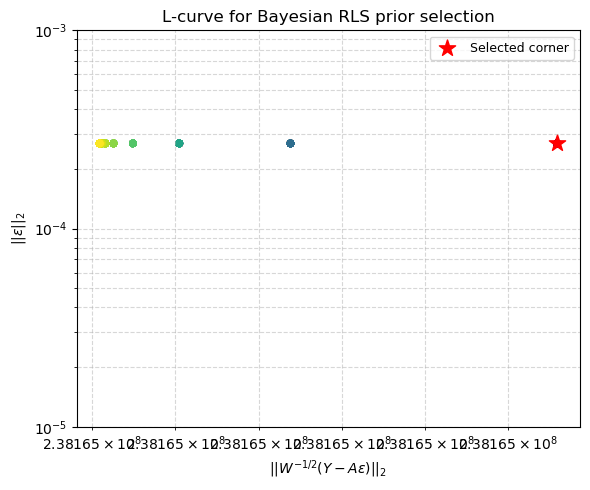

In [55]:
plot_L_curve(res.Lcurve)


In [56]:
kf_Eul=res.kf_final/2/np.pi
Fk_Eul=np.nanmean(res.Fk_all,axis=1)
Fk_Eul_std=np.nanstd(res.Fk_all,axis=1)*10

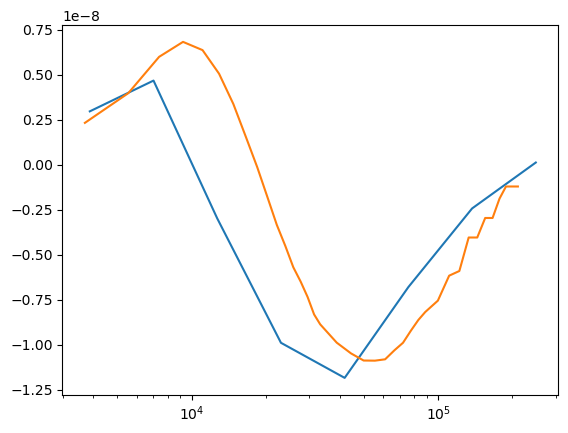

In [57]:
cgname='/meddy/simingzhang/Data/RB_iceland_data/s2sflux_spec_hf_kaiser_corr.0002.nc'
cg=xr.open_dataset(cgname)
filtscale=np.squeeze(cg['filtscale'][1:])
Th_Eul=cg['Thm'].values[1:]
plt.semilogx(1/kf_Eul,Fk_Eul)
plt.fill_between(1/kf_Eul,Fk_Eul+Fk_Eul_std,Fk_Eul-Fk_Eul_std,alpha=0.4)

plt.semilogx(filtscale,Th_Eul)


In [3]:
A=sio.loadmat('/meddy/simingzhang/Analysis/matlab/HIT2d_Eulerian_SF3.mat')

In [28]:
dist_axis=np.squeeze(A['r'])[1:]
# SF3=(A['SF3'])[:,1:].T
SF3=(A['S3L1_time']+A['S3T1_time'])[:,1:].T

In [29]:
SpecFlux, Vt, ebs, kf, lf=  RLS_Tikhonov(SF3, dist_axis, 0.03,6.28,'RLS',1e-3,12)

In [ ]:
plt.semilogx(1/kf,np.nanmean(SpecFlux,axis=1))

(199, 362)